In [2]:
# ==========================================
# PHASE 1: RE-INITIALISATION & DEPENDENCIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Ensure our plots look crisp and high-end
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = (10, 6)




In [3]:
# ==========================================
# PHASE 2: FEATURE ENGINEERING & SCALING
# ==========================================
# Load your existing file (assuming it's in your Colab files directory)
df_customer = pd.read_csv('retail_sales_dataset.csv')

# We extract Age and Total Amount for behavioral tracking
X = df_customer[['Age', 'Total Amount']]

# Standardise features so variance scales equally (Mean = 0, Std Dev = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features extracted and normalised successfully!")


✅ Features extracted and normalised successfully!


In [4]:
df_customer.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


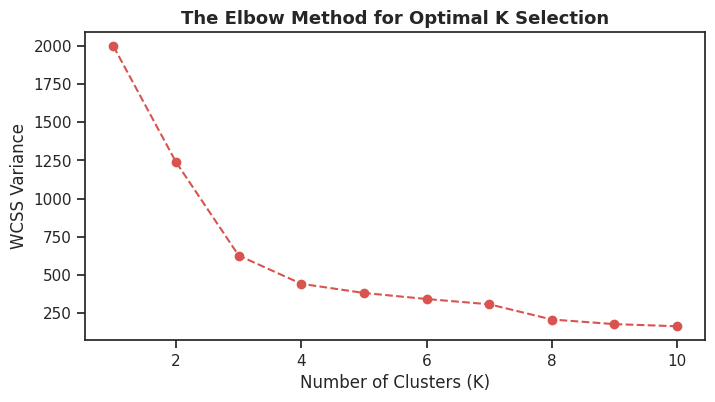

In [5]:
# ==========================================
# PHASE 3: THE ELBOW METHOD (OPTIMAL 'K')
# ==========================================
wcss = []  # Within-Cluster Sum of Squares

# Run tests for 1 to 10 potential clusters
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the mathematical Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='#d9534f')
plt.title('The Elbow Method for Optimal K Selection', fontsize=13, weight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS Variance')
plt.show()


In [6]:
# ==========================================
# PHASE 4: K-MEANS MODEL EXECUTION
# ==========================================
# Apply K-Means using 3 structural segments
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df_customer['Cluster_ID'] = kmeans.fit_transform(X_scaled).argmin(axis=1) # Alternative cluster assignment labels

# Swap numerical IDs to meaningful business group labels
cluster_labels = {
    0: "Cluster A: High-Spending Diverse Shoppers",
    1: "Cluster B: Budget-Conscious Younger Consumers",
    2: "Cluster C: Conservative Mature Buyers"
}
df_customer['Segment Name'] = df_customer['Cluster_ID'].map(cluster_labels)

print("✅ Clustering algorithm execution finalized!")
df_customer[['Age', 'Total Amount', 'Segment Name']].head()


✅ Clustering algorithm execution finalized!


,Age,Total Amount,Segment Name
0,34,150,Cluster A: High-Spending Diverse Shoppers
1,26,1000,Cluster B: Budget-Conscious Younger Consumers
2,50,30,Cluster C: Conservative Mature Buyers
3,37,500,Cluster A: High-Spending Diverse Shoppers
4,30,100,Cluster A: High-Spending Diverse Shoppers


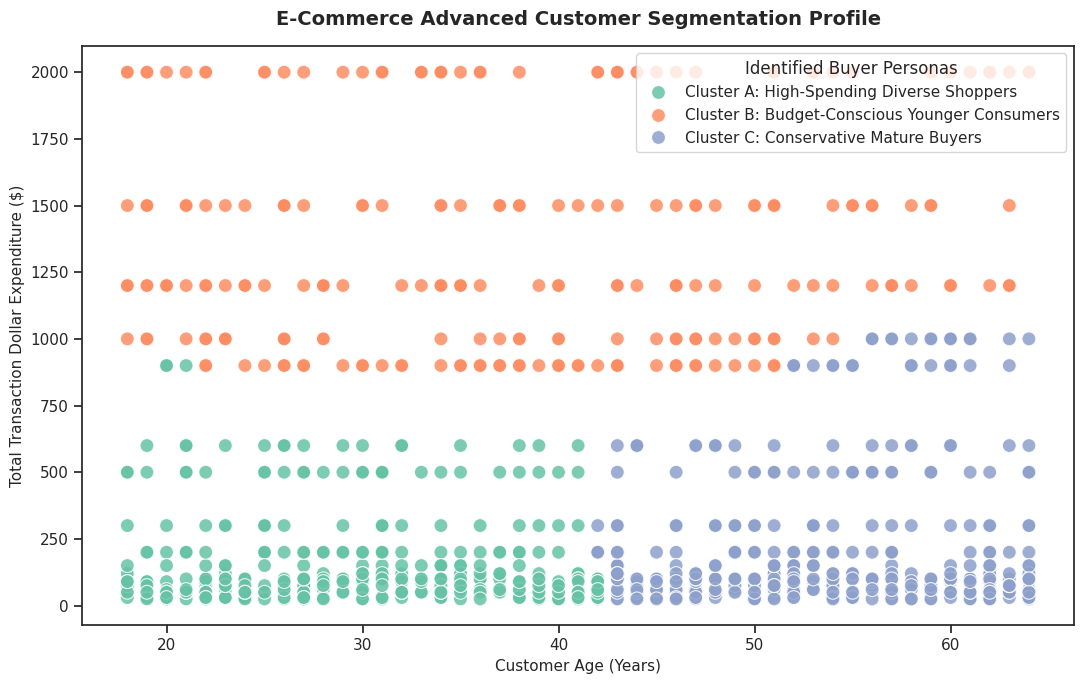

In [7]:
# ==========================================
# PHASE 5: SEGMENTATION VISUALISATION
# ==========================================
plt.figure(figsize=(11, 7))

# Plot actual consumer distributions colored by cluster
sns.scatterplot(
    data=df_customer,
    x='Age',
    y='Total Amount',
    hue='Segment Name',
    palette='Set2',
    s=100,
    alpha=0.85,
    edgecolor='w'
)

plt.title('E-Commerce Advanced Customer Segmentation Profile', fontsize=14, weight='bold', pad=15)
plt.xlabel('Customer Age (Years)', fontsize=11)
plt.ylabel('Total Transaction Dollar Expenditure ($)', fontsize=11)
plt.legend(title='Identified Buyer Personas', loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


In [ ]:
## 🎯 Project 2 Conclusion & Marketing Recommendations

### 📊 Cluster Archetypes Discovered
# 1. **High-Spending Diverse Shoppers:** Customers across multiple age brackets who consistently generate large basket sizes. This is our primary revenue engine.
# 2. **Budget-Conscious Younger Consumers:** Younger buyers who visit frequently but make low-value individual purchases.
# 3. **Conservative Mature Buyers:** Older demographic tiers exhibiting targeted, medium-to-low-value transaction behavior.

### 📈 Actionable Retail Strategies
# **For High-Spenders:** Enroll them automatically into an elite VIP/Loyalty program with exclusive early access to major product drops.
# **For Budget Younger Shoppers:** Implement buy-now-pay-later (BNPL) structures, student discounts, and gamified app rewards to increase transaction scale.
# **For Mature Buyers:** Use direct email marketing campaigns focusing on utility, warranty, and high product reliability scores.
